In [1]:
!pip install torch --index-url https://download.pytorch.org/whl/cu128
!pip -q install -U deepxde
!pip install numpy
import os
os.environ["DDE_BACKEND"] = "pytorch"

import torch
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

Looking in indexes: https://download.pytorch.org/whl/cu128


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# Model parameters
r_true, gu_true = 0.39, 0.05
Nm, n = 0.89, 2.5
gL = 0.005
a_scale, bu_scale, uth_scale = 1.58, 15.8, 0.7
uth_e_scale = 0.75
N0 = 0.0000798
scale_factor = 1e-7

# Real values
# bL_scale_true = 0.8
# gLu_scale_true = 0.3

# Reference solution
def get_ground_truth_solution():
    t_span, t_eval = (0, 200), np.linspace(0, 200, 2000)
    y0 = [N0, 0.0, 0.0]
    def rhs(t, y):
        N, u, L = max(y[0], 0), max(y[1], 0), max(y[2], 0)
        dN = r_true * N * (1 - N / Nm)
        hill_u = (u**n) / ((7e-8) ** n + u ** n + 1e-20)
        du = (N / Nm) * (1.58e-7 + 1.58e-6 * hill_u) - gu_true * u - 3e6 * u * L
        hill_L = (u ** n) / ((7.5e-8) ** n + u ** n + 1e-20)
        dL = 8e-8 * (N / Nm) * hill_L - gL * L
        return [dN, du, dL]
    sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, method='Radau', rtol=1e-8, atol=1e-11)
    return (interp1d(sol.t, sol.y[0], kind='cubic'),
            interp1d(sol.t, sol.y[1]/scale_factor, kind='cubic'),
            interp1d(sol.t, sol.y[2]/scale_factor, kind='cubic'))

interp_N_true, interp_U_true, interp_V_true = get_ground_truth_solution()
t_exp = np.linspace(0, 200, 40).reshape(-1, 1)
y_N_true, y_U_true, y_V_true = interp_N_true(t_exp), interp_U_true(t_exp), interp_V_true(t_exp)
noise_level = 0.03
y_N_exp = y_N_true + noise_level*np.std(y_N_true)*np.random.randn(*y_N_true.shape)
y_U_exp = y_U_true + noise_level*np.std(y_U_true)*np.random.randn(*y_U_true.shape)
y_V_exp = y_V_true + noise_level*np.std(y_V_true)*np.random.randn(*y_V_true.shape)

# Parameters to predict
unscaled_bL = dde.Variable(0.0)
unscaled_gLu = dde.Variable(0.0)

def ode_system_inverse(t, y):
    N, U, V = y[:, 0:1], y[:, 1:2], y[:, 2:3]
    r = r_true
    gu = gu_true

    # bL_scale falls in [0.0, 1.0]
    bL_scale_inv = 0.5 * torch.tanh(unscaled_bL) + 0.5

    # gLu_scale falls in [0.0, 0.6]
    gLu_scale_inv = 0.3 * torch.tanh(unscaled_gLu) + 0.3

    # NN gradients
    dN_dt = dde.grad.jacobian(y, t, i=0, j=0)
    dU_dt = dde.grad.jacobian(y, t, i=1, j=0)
    dV_dt = dde.grad.jacobian(y, t, i=2, j=0)

    eq1 = dN_dt - r * N * (1.0 - N / Nm)

    U_safe = torch.abs(U) + 1e-8
    hill_u = (U_safe**n) / (uth_scale**n + U_safe**n)
    eq2 = dU_dt - (N/Nm)*(a_scale + bu_scale*hill_u) + gu*U + gLu_scale_inv*U*V

    hill_L = (U_safe**n) / (uth_e_scale**n + U_safe**n)
    eq3 = dV_dt - bL_scale_inv*(N/Nm)*hill_L + gL*V

    return [eq1, eq2, eq3]

In [3]:
# Setting data
geom = dde.geometry.TimeDomain(0, 200.0)
observe_N = dde.icbc.PointSetBC(t_exp, y_N_exp.astype(np.float32), component=0)
observe_U = dde.icbc.PointSetBC(t_exp, y_U_exp.astype(np.float32), component=1)
observe_V = dde.icbc.PointSetBC(t_exp, y_V_exp.astype(np.float32), component=2)

data = dde.data.PDE(geom, ode_system_inverse, [observe_N, observe_U, observe_V], num_domain=2500, num_test=1000)

net = dde.nn.FNN([1] + [64] * 5 + [3], "tanh", "Glorot normal")
net.apply_feature_transform(lambda t: t / 200.0)
model = dde.Model(data, net)

In [4]:
external_trainable_variables = [unscaled_bL, unscaled_gLu]
variable_saver = dde.callbacks.VariableValue(external_trainable_variables, period=1000, filename="variables_lactonase.dat")

# Model compilation
# Loss order: [eq1, eq2, eq3, N_exp, U_exp, V_exp]
loss_weights_schedule = [10, 10, 10, 100, 100, 100]

# Reducing Learning Rate for 5% (0.95) each 1000 steps.
model.compile(
    "adam",
    lr=0.001,
    loss_weights=loss_weights_schedule,
    decay=("step", 1000, 0.95),
    external_trainable_variables=external_trainable_variables
)

Compiling model...
'compile' took 1.251340 s



In [5]:
losshistory, train_state = model.train(iterations=30000, display_every=3000, callbacks=[variable_saver])

final_unscaled_bL = external_trainable_variables[0].detach().item()
final_unscaled_gLu = external_trainable_variables[1].detach().item()

found_bL_scale = 0.5 * np.tanh(final_unscaled_bL) + 0.5
found_gLu_scale = 0.3 * np.tanh(final_unscaled_gLu) + 0.3

print(f"True bL_scale: 0.8  | Predicted bL_scale: {found_bL_scale:.4f}")
print(f"True gLu_scale: 0.3 | Predicted gLu_scale: {found_gLu_scale:.4f}")

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [1.69e-03, 4.26e-02, 1.16e-05, 7.30e+01, 1.39e+03, 1.15e+05]    [1.69e-03, 4.27e-02, 1.16e-05, 7.30e+01, 1.39e+03, 1.15e+05]    []  
3000      [4.53e-03, 6.22e-01, 7.58e-02, 2.18e-01, 3.29e+00, 2.44e+01]    [4.53e-03, 6.23e-01, 7.60e-02, 2.18e-01, 3.29e+00, 2.44e+01]    []  
6000      [2.73e-03, 2.79e-01, 2.96e-01, 9.89e-02, 1.01e+00, 8.63e+00]    [2.71e-03, 2.81e-01, 2.97e-01, 9.89e-02, 1.01e+00, 8.63e+00]    []  
9000      [2.55e-03, 2.09e-01, 3.27e-01, 9.33e-02, 4.81e-01, 3.20e+00]    [2.53e-03, 2.10e-01, 3.28e-01, 9.33e-02, 4.81e-01, 3.20e+00]    []  
12000     [3.04e-03, 1.86e-01, 3.63e-01, 9.67e-02, 2.83e-01, 1.02e-01]    [3.01e-03, 1.87e-01, 3.63e-01, 9.67e-02, 2.83e-01, 1.02e-01]    []  
15000     [2.79e-03, 1.19e-01, 3.61e-01, 7.03e-02, 2.43e-01, 1.09e-02]    [2.77e-03, 1.20e-01, 3.62e-01, 7.03e-02, 2

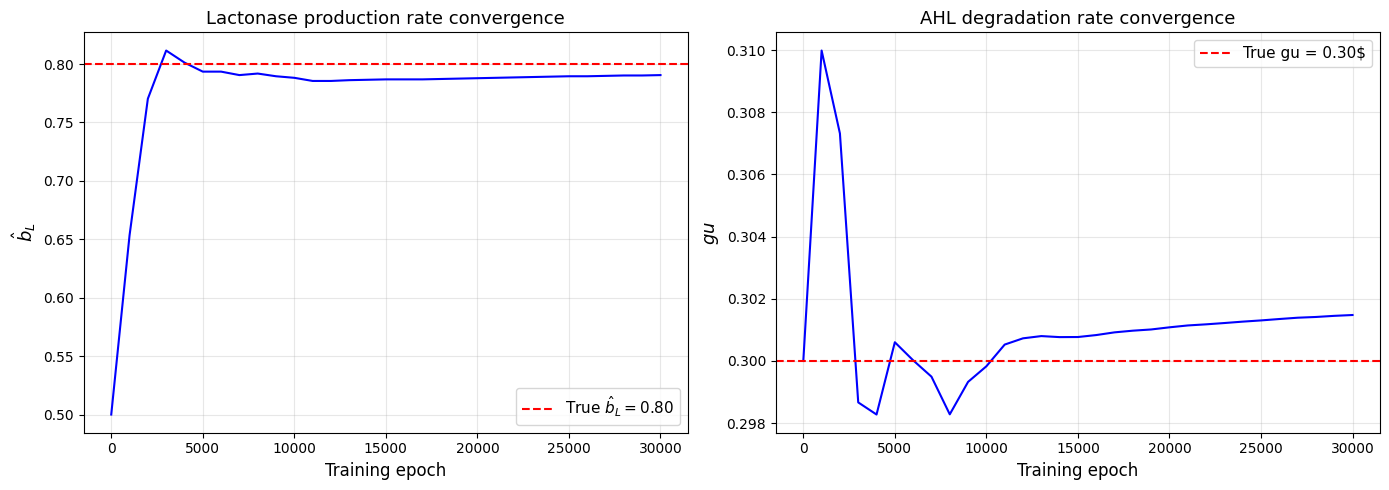

In [6]:
# ============================================================
# FIGURE 2: Parameter Convergence
# ============================================================
import re

epochs_var = []
raw_bL = []
raw_gLu = []

with open('variables_lactonase.dat', 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        line_clean = line.replace('[', '').replace(']', '')
        values = [float(x) for x in re.split(r'[,\s]+', line_clean) if x]
        if len(values) >= 3:
            epochs_var.append(values[0])
            raw_bL.append(values[1])
            raw_gLu.append(values[2])

epochs_var = np.array(epochs_var)
raw_bL = np.array(raw_bL)
raw_gLu = np.array(raw_gLu)

# Apply the same bounding transformation used during training
bL_history = 0.5 * np.tanh(raw_bL) + 0.5
gLu_history = 0.3 * np.tanh(raw_gLu) + 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_var, bL_history, 'b-', linewidth=1.5)
axes[0].axhline(y=0.8, color='r', linestyle='--', linewidth=1.5,
                label=r'True $\hat{b}_L = 0.80$')
axes[0].set_xlabel('Training epoch', fontsize=12)
axes[0].set_ylabel(r'$\hat{b}_L$', fontsize=13)
axes[0].set_title('Lactonase production rate convergence', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_var, gLu_history, 'b-', linewidth=1.5)
axes[1].axhline(y=0.3, color='r', linestyle='--', linewidth=1.5,
                label=r'True gu = 0.30$')
axes[1].set_xlabel('Training epoch', fontsize=12)
axes[1].set_ylabel(r'$gu$', fontsize=13)
axes[1].set_title('AHL degradation rate convergence', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inverse_parameter_convergence.png', dpi=300, bbox_inches='tight')
plt.savefig('inverse_parameter_convergence.pdf', bbox_inches='tight')
plt.show()

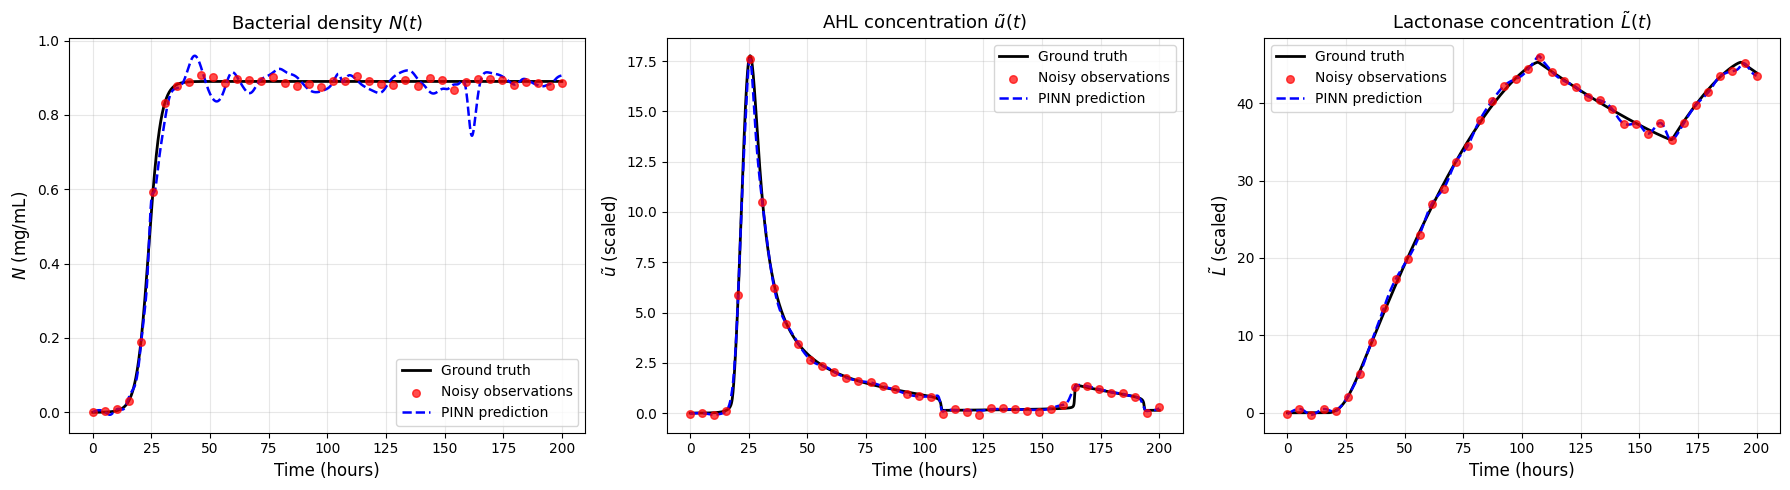

In [7]:
# ============================================================
# POST-TRAINING VISUALISATION — Experiment 3 (Inverse Problem)
# ============================================================

# --- A. Predict PINN solution on dense grid ---
t_dense = np.linspace(0, 200, 2000).reshape(-1, 1)
y_pred = model.predict(t_dense)  # shape (2000, 3)

N_pred = y_pred[:, 0]
U_pred = y_pred[:, 1]
V_pred = y_pred[:, 2]

# Ground-truth on same grid (scaled)
N_gt = interp_N_true(t_dense.flatten())
U_gt = interp_U_true(t_dense.flatten())
V_gt = interp_V_true(t_dense.flatten())

t_plot = t_dense.flatten()

# ============================================================
# FIGURE 1: Trajectory Reconstruction (3 subplots)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- N(t) ---
axes[0].plot(t_plot, N_gt, 'k-', linewidth=2, label='Ground truth')
axes[0].scatter(t_exp.flatten(), y_N_exp.flatten(),
                c='red', s=30, zorder=5, alpha=0.7, label='Noisy observations')
axes[0].plot(t_plot, N_pred, 'b--', linewidth=1.8, label='PINN prediction')
axes[0].set_xlabel('Time (hours)', fontsize=12)
axes[0].set_ylabel(r'$N$ (mg/mL)', fontsize=12)
axes[0].set_title(r'Bacterial density $N(t)$', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# --- u(t) scaled ---
axes[1].plot(t_plot, U_gt, 'k-', linewidth=2, label='Ground truth')
axes[1].scatter(t_exp.flatten(), y_U_exp.flatten(),
                c='red', s=30, zorder=5, alpha=0.7, label='Noisy observations')
axes[1].plot(t_plot, U_pred, 'b--', linewidth=1.8, label='PINN prediction')
axes[1].set_xlabel('Time (hours)', fontsize=12)
axes[1].set_ylabel(r'$\tilde{u}$ (scaled)', fontsize=12)
axes[1].set_title(r'AHL concentration $\tilde{u}(t)$', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# --- L(t) scaled ---
axes[2].plot(t_plot, V_gt, 'k-', linewidth=2, label='Ground truth')
axes[2].scatter(t_exp.flatten(), y_V_exp.flatten(),
                c='red', s=30, zorder=5, alpha=0.7, label='Noisy observations')
axes[2].plot(t_plot, V_pred, 'b--', linewidth=1.8, label='PINN prediction')
axes[2].set_xlabel('Time (hours)', fontsize=12)
axes[2].set_ylabel(r'$\tilde{L}$ (scaled)', fontsize=12)
axes[2].set_title(r'Lactonase concentration $\tilde{L}(t)$', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inverse_trajectory_reconstruction.png', dpi=300, bbox_inches='tight')
plt.savefig('inverse_trajectory_reconstruction.pdf', bbox_inches='tight')
plt.show()


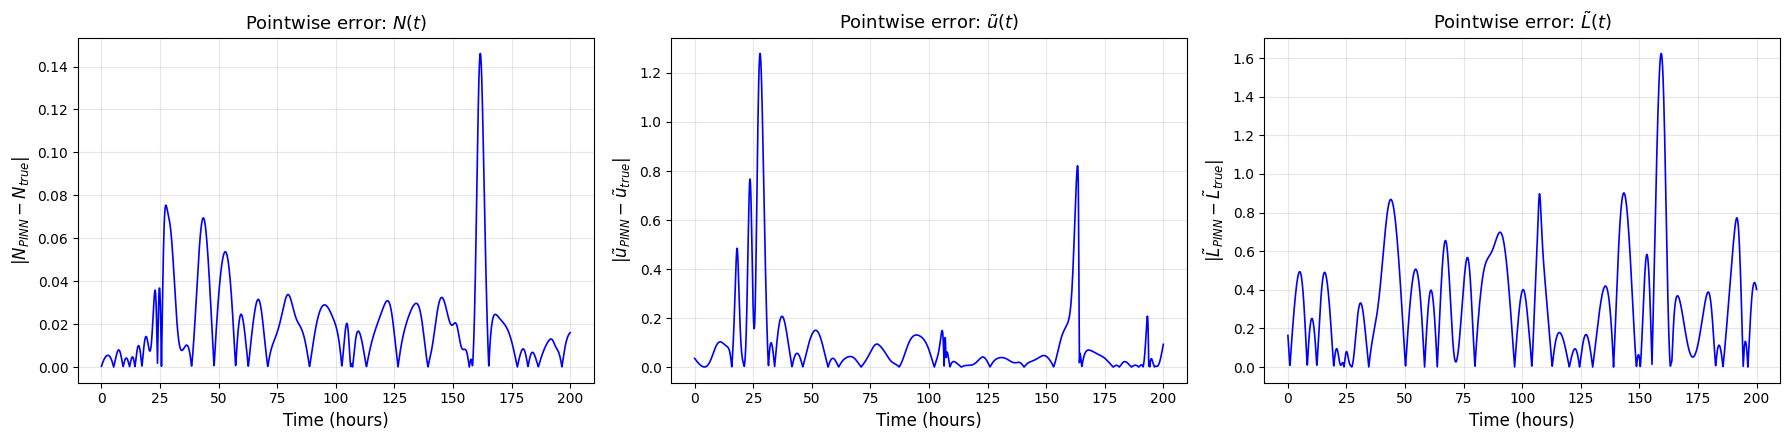


========== SUMMARY ==========
L2 relative error N:  3.42%
L2 relative error u:  5.00%
L2 relative error L:  1.26%
bL  : true=0.800, found=0.7905, error=1.18%
gLu : true=0.300, found=0.3015, error=0.49%
Training time: 1552.1 s (25.9 min)


In [8]:

# ============================================================
# FIGURE 4: Pointwise Absolute Error
# ============================================================
err_N = np.abs(N_pred - N_gt)
err_U = np.abs(U_pred - U_gt)
err_V = np.abs(V_pred - V_gt)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(t_plot, err_N, 'b-', linewidth=1.2)
axes[0].set_xlabel('Time (hours)', fontsize=12)
axes[0].set_ylabel(r'$|N_{PINN} - N_{true}|$', fontsize=12)
axes[0].set_title(r'Pointwise error: $N(t)$', fontsize=13)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_plot, err_U, 'b-', linewidth=1.2)
axes[1].set_xlabel('Time (hours)', fontsize=12)
axes[1].set_ylabel(r'$|\tilde{u}_{PINN} - \tilde{u}_{true}|$', fontsize=12)
axes[1].set_title(r'Pointwise error: $\tilde{u}(t)$', fontsize=13)
axes[1].grid(True, alpha=0.3)

axes[2].plot(t_plot, err_V, 'b-', linewidth=1.2)
axes[2].set_xlabel('Time (hours)', fontsize=12)
axes[2].set_ylabel(r'$|\tilde{L}_{PINN} - \tilde{L}_{true}|$', fontsize=12)
axes[2].set_title(r'Pointwise error: $\tilde{L}(t)$', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('inverse_pointwise_error.png', dpi=300, bbox_inches='tight')
plt.savefig('inverse_pointwise_error.pdf', bbox_inches='tight')
plt.show()

# ============================================================
# Print summary table for LaTeX
# ============================================================
L2_N = np.sqrt(np.mean(err_N**2)) / (np.sqrt(np.mean(N_gt**2)) + 1e-15) * 100
L2_U = np.sqrt(np.mean(err_U**2)) / (np.sqrt(np.mean(U_gt**2)) + 1e-15) * 100
L2_V = np.sqrt(np.mean(err_V**2)) / (np.sqrt(np.mean(V_gt**2)) + 1e-15) * 100

print("\n========== SUMMARY ==========")
print(f"L2 relative error N:  {L2_N:.2f}%")
print(f"L2 relative error u:  {L2_U:.2f}%")
print(f"L2 relative error L:  {L2_V:.2f}%")
print(f"bL  : true=0.800, found={found_bL_scale:.4f}, error={abs(found_bL_scale-0.8)/0.8*100:.2f}%")
print(f"gLu : true=0.300, found={found_gLu_scale:.4f}, error={abs(found_gLu_scale-0.3)/0.3*100:.2f}%")
print(f"Training time: 1552.1 s ({1552.1/60:.1f} min)")